# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [5]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [6]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print('Tỷ lệ missing của các cột:')
print(df.isnull().mean() * 100)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']
df = df.drop(columns=leaky)

print("\nCác cột còn lại:", list(df.columns))

Tỷ lệ missing của các cột:
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột `alive` được suy ra trực tiếp từ `survived`. survived=1 thì alive='yes', survived=0 thì alive='no'. Nếu giữ lại alive thì mô hình sẽ biết được kết quả chính xác dựa vào survived. Từ đó rò rỉ target.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [7]:
# TODO 2: shape, info, describe
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")
print("Biến mục tiêu (target): survived")

print("\n--- df.info() ---")
df.info()

print("\n--- df.describe() cho biến số ---")
display(df.describe())

print("\n--- df.describe(include=\"object\") cho biến phân loại ---")
display(df.describe(include="object"))

Số dòng: 891, Số cột: 8
Biến mục tiêu (target): survived

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB

--- df.describe() cho biến số ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- df.describe(include="object") cho biến phân loại ---


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

*   Biến số: pclass, age, sibsp, parch, fare.
*   Biến phân loại: survived, sex, embarked.

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [20]:
# TODO 3: bảng missing (count + %)
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_table = pd.DataFrame({'Missing Count': missing_data, 'Missing Percentage (%)': missing_percentage})


print("Bảng thống kê Missing Values:")
display(missing_table)

Bảng thống kê Missing Values:


,Missing Count,Missing Percentage (%)
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| age | ~19.87% | Điền giá trị median | age là biến số, điền median giúp tránh bị ảnh hưởng bởi outlier và giữ phân phối tốt hơn so với mean. |
| embarked | ~0.22% | Điền giá trị mode (phổ biến nhất) | embarked là biến phân loại có rất ít giá trị thiếu, điền mode là cách hợp lý và ít gây sai lệch nhất. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [10]:
import numpy as np
from scipy import stats

# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return ((s < low) | (s > high)).sum(), (low, high)

def dem_outlier_zscore(s, nguong=3.0):
    s_cleaned = s.dropna()
    z_scores = np.abs(stats.zscore(s_cleaned))
    return (z_scores > nguong).sum()

print("Số lượng outlier:")
for col in ["age", "fare"]:
    n_out_iqr, (low_iqr, high_iqr) = dem_outlier_iqr(df[col])
    n_out_zscore = dem_outlier_zscore(df[col])
    print(f"{col:5s}: IQR outliers = {n_out_iqr:3d} (ngoài [{low_iqr:.1f}, {high_iqr:.1f}]) | Z-score(>3) = {n_out_zscore}")

Số lượng outlier:
age  : IQR outliers =  11 (ngoài [-6.7, 64.8]) | Z-score(>3) = 2
fare : IQR outliers = 116 (ngoài [-26.7, 65.6]) | Z-score(>3) = 20


**Trả lời 4 (quyết định với outlier của `fare`):**

Giữ lại outlier của `fare`. fare thể hiện giá, vé mắc tiền có thể thể hiện giàu nghèo và ảnh hưởng đến khả năng sống sót.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

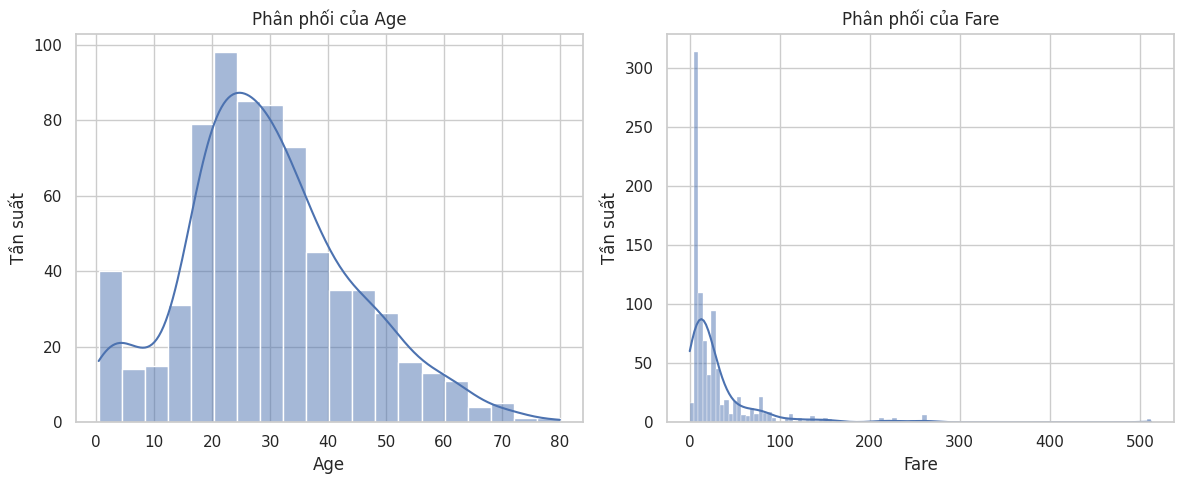

In [21]:
# TODO 5a: Histogram age & fare
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['age'].dropna(), kde=True)
plt.title('Phân phối của Age')
plt.xlabel('Age')
plt.ylabel('Tần suất')

plt.subplot(1, 2, 2)
sns.histplot(df['fare'], kde=True)
plt.title('Phân phối của Fare')
plt.xlabel('Fare')
plt.ylabel('Tần suất')

plt.tight_layout()
plt.show()

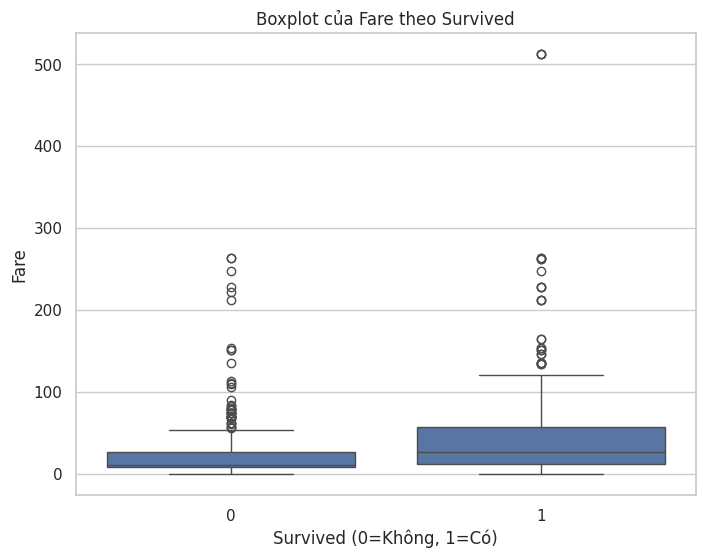

In [22]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(8, 6))
sns.boxplot(x='survived', y='fare', data=df)
plt.title('Boxplot của Fare theo Survived')
plt.xlabel('Survived (0=Không, 1=Có)')
plt.ylabel('Fare')
plt.show()

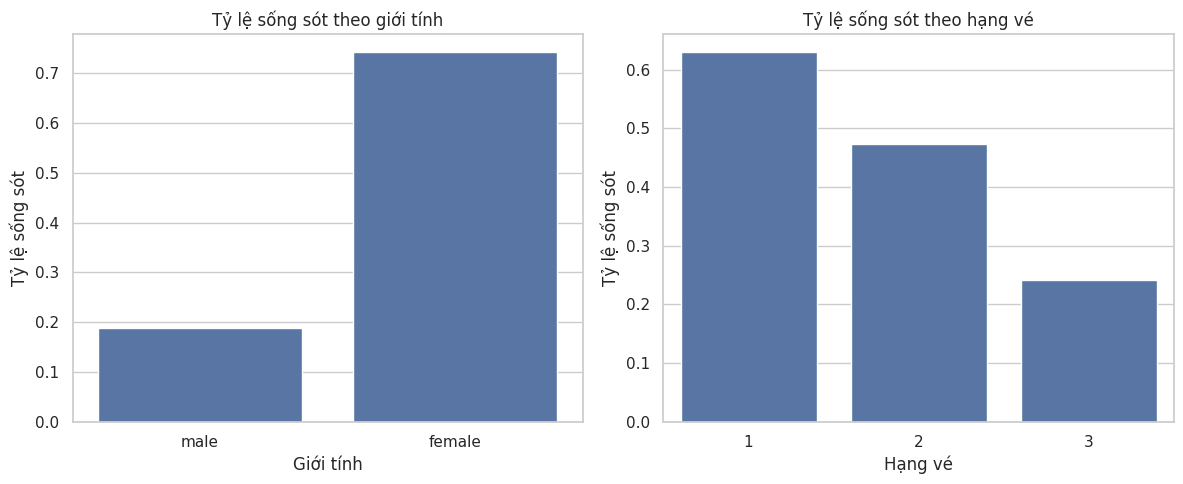

In [23]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='sex', y='survived', data=df, errorbar=None)
plt.title('Tỷ lệ sống sót theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Tỷ lệ sống sót')

plt.subplot(1, 2, 2)
sns.barplot(x='pclass', y='survived', data=df, errorbar=None)
plt.title('Tỷ lệ sống sót theo hạng vé')
plt.xlabel('Hạng vé')
plt.ylabel('Tỷ lệ sống sót')

plt.tight_layout()
plt.show()

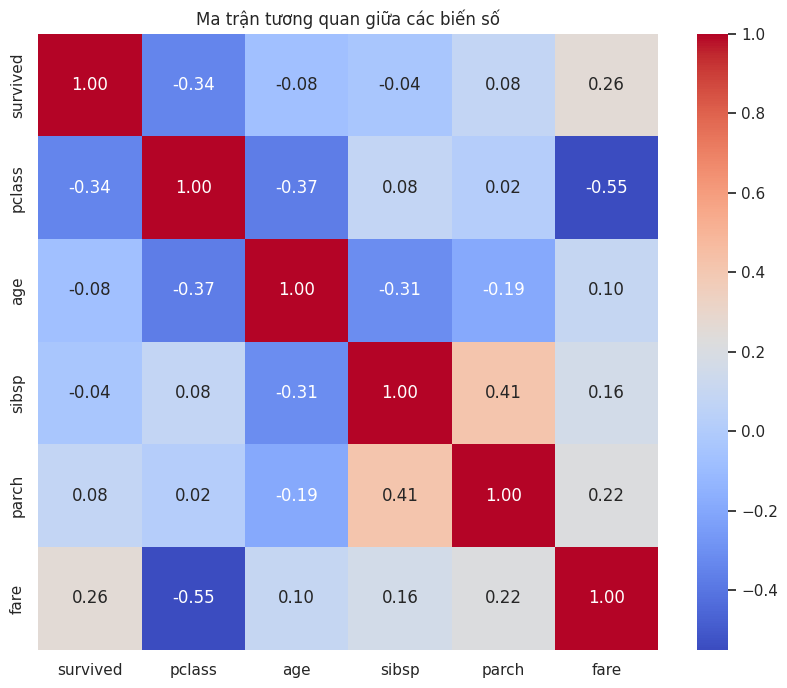

In [14]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- **Histogram (Age):** Gần giống phân phối chuẩn nhưng hơi lệch phải, dồn về phía tuổi trẻ hơn. Có một đỉnh ở độ tuổi 20-30.
- **Histogram (Fare):** Lệch phải rất mạnh. Suy ra đa phần khách đi vé giá rẻ.
- **Boxplot (Fare theo Survived):** Nhiều người sống sót (survived=1) trả giá vé cao hơn so với người không sống sót (survived=0). Trung vị của nhóm sống sót cao hơn, và phân phối của nhóm sống sót giá trị vé cao cũng rộng hơn.
- **Bar survival (theo Sex và Pclass):**
    - **Theo Sex:** Phụ nữ có tỷ lệ sống sót cao hơn(khoảng 74% với 19%).
    - **Theo Pclass:** Hạng nhất (First class) có tỷ lệ sống sót cao nhất, sau đó đến hạng hai (Second class), và hạng ba (Third class).
- **Heatmap:**
    - survived có tương quan dương mạnh nhất với fare (0.26) và tương quan âm mạnh nhất với pclass (-0.34). Nên có thể suy rằng người có vé đắt có khả năng sống cao hơn.
    - pclass và fare có tương quan âm mạnh (-0.55), hợp lý vì vé hạng cao thì giá đắt hơn.
    - age có tương quan âm nhẹ pclass (-0.37) và sibsp (-0.31).
    - sibsp và parch có tương quan 0.41, người đi cùng anh chị em/vợ chồng thường cũng đi cùng con cái/cha mẹ.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [15]:
# TODO 6: chia train/val/test có stratify
X = df.drop('survived', axis=1)
y = df['survived']

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=(0.15/0.85), random_state=42, stratify=y_tmp)

print(f"Train/Val/Test shapes: X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}")
print(f"                     y_train={y_train.shape}, y_val={y_val.shape}, y_test={y_test.shape}")

print("\nTỷ lệ survived trong các tập:")
print(f"  Train: {y_train.mean():.2f}")
print(f"  Validation: {y_val.mean():.2f}")
print(f"  Test: {y_test.mean():.2f}")

Train/Val/Test shapes: X_train=(623, 7), X_val=(134, 7), X_test=(134, 7)
                     y_train=(623,), y_val=(134,), y_test=(134,)

Tỷ lệ survived trong các tập:
  Train: 0.38
  Validation: 0.39
  Test: 0.38


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [16]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print(f"X_train_t shape: {X_train_t.shape}")
print(f"X_val_t shape: {X_val_t.shape}")
print(f"X_test_t shape: {X_test_t.shape}")
print("Tên cột sau tiền xử lý:", list(preprocess.get_feature_names_out()))

X_train_t shape: (623, 10)
X_val_t shape: (134, 10)
X_test_t shape: (134, 10)
Tên cột sau tiền xử lý: ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

fit chỉ trên train để tránh data leakage.

Các bước preprocessing học các tham số từ dữ liệu. Nếu được học từ toàn bộ dữ liệu, thông tin từ tập kiểm tra sẽ bị rò rỉ vào quá trình tiền xử lý.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [17]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
survived_counts = df['survived'].value_counts()
survived_ratio = df['survived'].value_counts(normalize=True)
print("Số lượng lớp 'survived':")
print(survived_counts)
print("\nTỷ lệ lớp 'survived':")
print(survived_ratio)

Số lượng lớp 'survived':
survived
0    549
1    342
Name: count, dtype: int64

Tỷ lệ lớp 'survived':
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1.  `survived` **có mất cân bằng**. Tỷ lệ lớp 0 (không sống sót) là khoảng 61.6% và lớp 1 (sống sót) là khoảng 38.4%.

2.  Nếu chỉ nhìn vào **Accuracy**, có thể bị đánh lừa trong trường hợp dữ liệu bị mất cân bằng. Ví dụ, nếu một mô hình luôn dự đoán hành khách **không sống sót** (lớp 0), nó vẫn sẽ đạt độ chính xác ~61.6%.

3.  Với bài toán Titanic, tôi ưu tiên **F1-score** hoặc **Recall** cho lớp `survived=1` (người sống sót). Lý do:
    *   **F1-score:** Kết hợp Precision và Recall. Nó được ưu tiên khi dữ liệu mất cân bằng.
    *   **Recall:** Nếu cần xác định được càng nhiều người sống sót càng tốt (giảm thiểu FN) thì Recall được ưu tiên hơn.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1.  **Đặc trưng tương quan mạnh nhất với khả năng sống sót:**
    *   `sex`: Phụ nữ có tỷ lệ sống sót cao hơn.
    *   `pclass`: Có tương quan âm mạnh với survived (-0.34 trên heatmap).
    *   `fare`: Có tương quan dương mạnh với survived (0.26 trên heatmap).

2.  **Cột thiếu nhiều nhất và cách xử lý:** Cột `age` thiếu nhiều nhất với gần 20% (177 giá trị). Để xử lý, điền median vì age là biến số và median giảm ảnh hưởng của các outlier.

3.  **Biến mục tiêu có mất cân bằng, ảnh hưởng đến metric:** Biến mục tiêu `survived` có mất cân bằng, 'không sống sót' chiếm khoảng 61.6% và 'sống sót' chiếm 38.4%. Chỉ sử dụng Accuracy có thể gây hiểu lầm. F1-score hoặc Recall (cho survived) sẽ là các metric phù hợp hơn.

4.  **Đặc trưng cần scaling vs encoding:**
    *   **Scaling:** age, sibsp, parch, fare
    *   **Encoding:** sex và embarked

5.  **Điều bất ngờ / thú vị:** `fare` có nhiều giá trị ngoại lai (116 outlier theo IQR, 20 theo Z-score), nhưng được giữ lại. Và có người sẵn sàng bỏ ra hơn 500 trong khi phần lớn trả chưa tới 50.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [ ]:
# (tùy chọn) code cho phần Bonus
...

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
